# 📊 Customer Churn Analytics for Business Decision Support
**Summer Internship Project** | Business Analytics & Machine Learning

---

## Executive Summary & Overview

### Problem Statement
Customer churn directly impacts recurring revenue and increases customer acquisition costs in the telecommunications sector. Retaining existing customers is significantly more cost-effective than acquiring new ones. This project analyzes customer behavioral patterns to identify key drivers of churn and deploy predictive models that assist management in proactive retention strategies.

### Business Context
In a highly competitive market, telecom operators face subscription cancellations due to pricing, service quality, or contract flexibility. Understanding *why* and *when* customers leave enables executives to design targeted intervention strategies, optimize marketing spend, and maximize Customer Lifetime Value (CLV).

### Objectives
* **Exploratory Analytics:** Identify primary demographic, financial, and operational drivers of churn.
* **Predictive Modeling:** Train and evaluate classification algorithms (Logistic Regression, Decision Tree, Random Forest) emphasizing recall and business utility.
* **Actionable Insights:** Translate analytical findings into data-driven retention strategies and policy recommendations.

In [7]:
# Import data and libraries

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)

# Styling configuration
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
pd.set_option('display.max_columns', None)

# Direct dataset URL (IBM Telco Customer Churn repository)
DATA_URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

# Load Dataset directly via pandas
print("Fetching IBM Telco Customer Churn dataset...")
df = pd.read_csv(DATA_URL)
print("Dataset successfully loaded!\n")

# Display overview
print("--- Dataset Summary ---")
display(df.head())

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Missing Values: {df.isnull().sum().sum()}")
print("\nTarget Variable ('Churn') Distribution:")
display(df['Churn'].value_counts(normalize=True).round(4) * 100)

Fetching IBM Telco Customer Churn dataset...
Dataset successfully loaded!

--- Dataset Summary ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Dataset Shape: 7043 rows, 21 columns
Missing Values: 0

Target Variable ('Churn') Distribution:


,proportion
Churn,
No,73.46
Yes,26.54


In [2]:
# Data Cleaning & Preprocessing

# 1. Drop identifier column
df_clean = df.drop(columns=['customerID'])

# 2. Convert TotalCharges to numeric (handle blank spaces)
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'].str.strip(), errors='coerce')

# 3. Handle missing values generated by conversion (impute with median)
missing_count = df_clean['TotalCharges'].isnull().sum()
if missing_count > 0:
    df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median(), inplace=True)

# 4. Remove duplicate rows if any
duplicates = df_clean.duplicated().sum()
if duplicates > 0:
    df_clean.drop_duplicates(inplace=True)

# Verification summary
cleaning_summary = pd.DataFrame({
    'Metric': ['Initial Rows', 'Cleaned Rows', 'Imputed TotalCharges', 'Duplicates Removed'],
    'Value': [len(df), len(df_clean), missing_count, duplicates]
})

display(cleaning_summary)

,Metric,Value
0,Initial Rows,7043
1,Cleaned Rows,7021
2,Imputed TotalCharges,11
3,Duplicates Removed,22


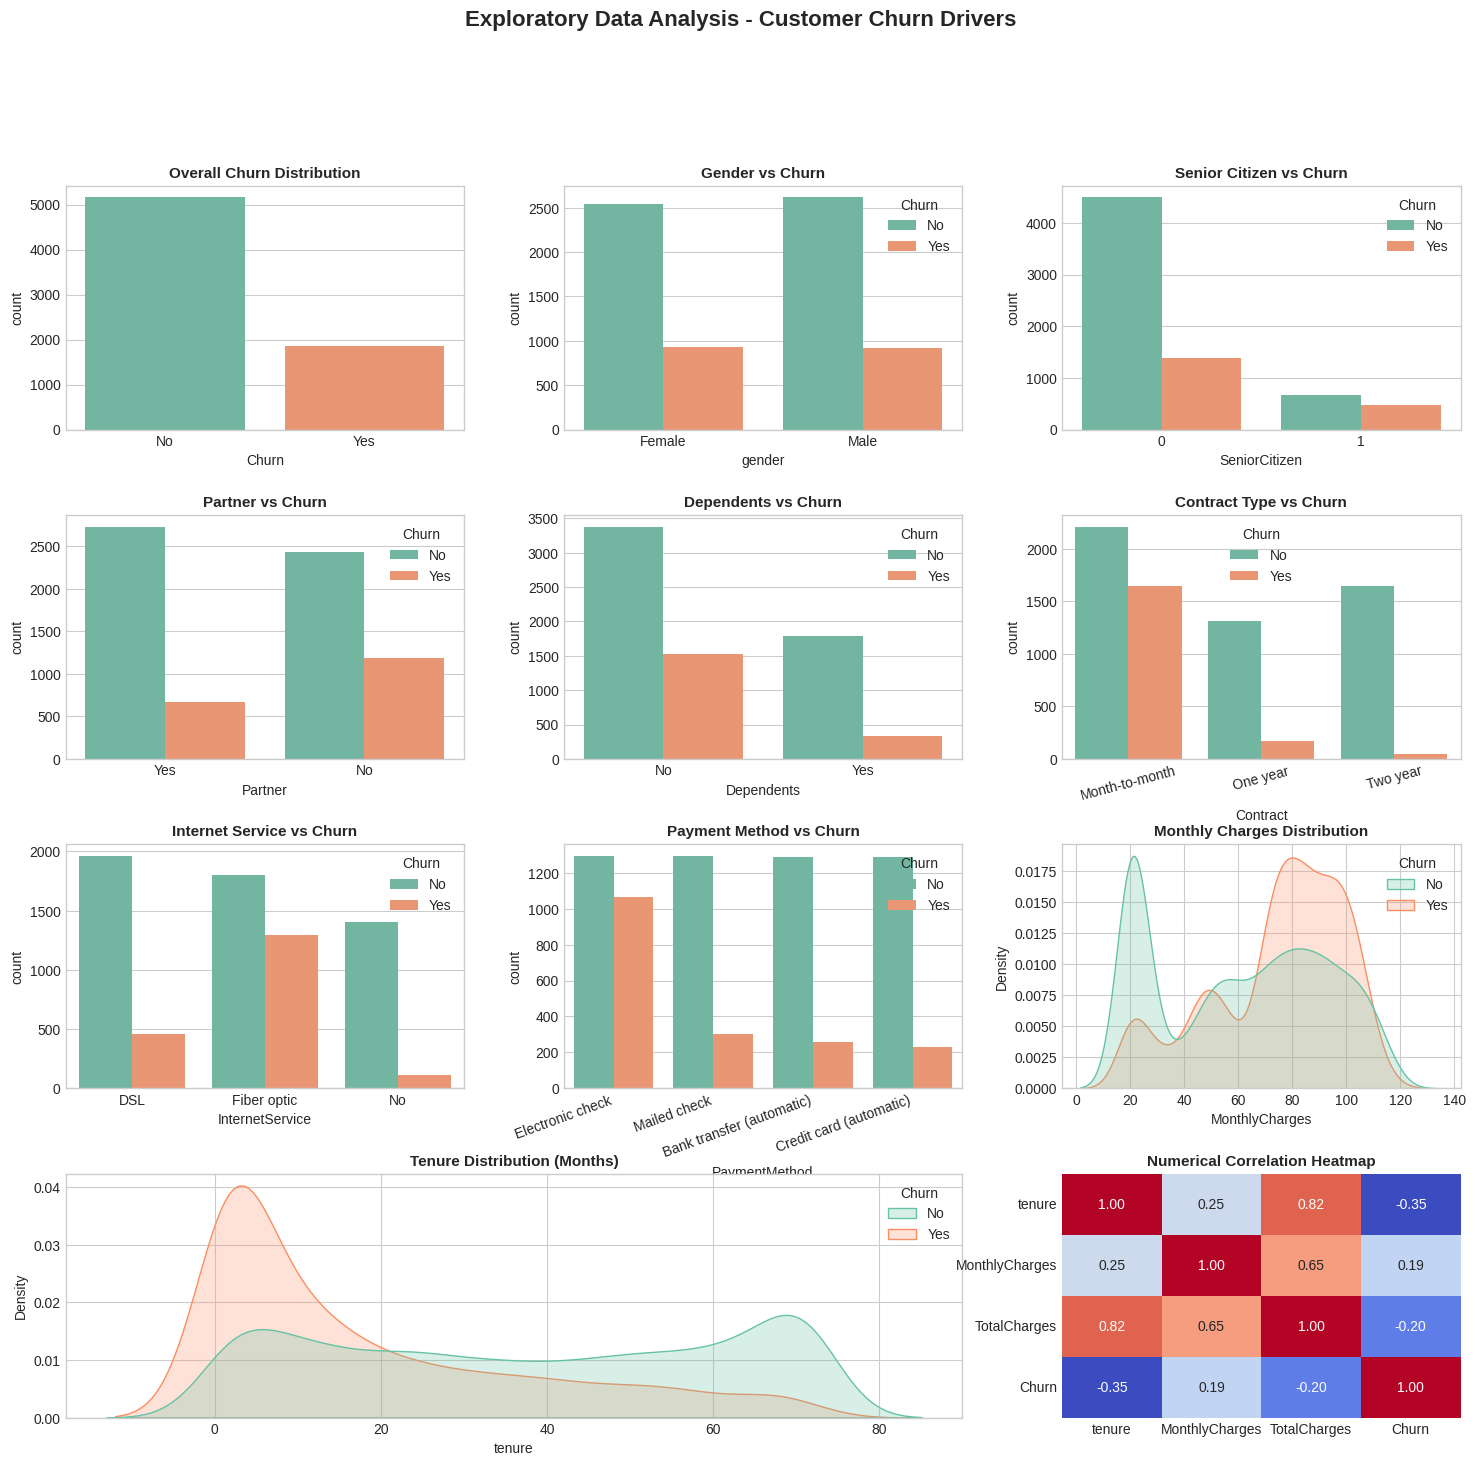

In [3]:
# Exploratory Data Analysis (EDA)

fig = plt.figure(figsize=(18, 16))
gs = fig.add_gridspec(4, 3, hspace=0.35, wspace=0.25)

# 1. Target Distribution
ax1 = fig.add_subplot(gs[0, 0])
sns.countplot(data=df_clean, x='Churn', palette='Set2', ax=ax1)
ax1.set_title('Overall Churn Distribution', fontsize=11, fontweight='bold')

# 2. Gender vs Churn
ax2 = fig.add_subplot(gs[0, 1])
sns.countplot(data=df_clean, x='gender', hue='Churn', palette='Set2', ax=ax2)
ax2.set_title('Gender vs Churn', fontsize=11, fontweight='bold')

# 3. Senior Citizen vs Churn
ax3 = fig.add_subplot(gs[0, 2])
sns.countplot(data=df_clean, x='SeniorCitizen', hue='Churn', palette='Set2', ax=ax3)
ax3.set_title('Senior Citizen vs Churn', fontsize=11, fontweight='bold')

# 4. Partner vs Churn
ax4 = fig.add_subplot(gs[1, 0])
sns.countplot(data=df_clean, x='Partner', hue='Churn', palette='Set2', ax=ax4)
ax4.set_title('Partner vs Churn', fontsize=11, fontweight='bold')

# 5. Dependents vs Churn
ax5 = fig.add_subplot(gs[1, 1])
sns.countplot(data=df_clean, x='Dependents', hue='Churn', palette='Set2', ax=ax5)
ax5.set_title('Dependents vs Churn', fontsize=11, fontweight='bold')

# 6. Contract Type vs Churn
ax6 = fig.add_subplot(gs[1, 2])
sns.countplot(data=df_clean, x='Contract', hue='Churn', palette='Set2', ax=ax6)
ax6.set_title('Contract Type vs Churn', fontsize=11, fontweight='bold')
ax6.tick_params(axis='x', rotation=15)

# 7. Internet Service vs Churn
ax7 = fig.add_subplot(gs[2, 0])
sns.countplot(data=df_clean, x='InternetService', hue='Churn', palette='Set2', ax=ax7)
ax7.set_title('Internet Service vs Churn', fontsize=11, fontweight='bold')

# 8. Payment Method vs Churn
ax8 = fig.add_subplot(gs[2, 1])
sns.countplot(data=df_clean, x='PaymentMethod', hue='Churn', palette='Set2', ax=ax8)
ax8.set_title('Payment Method vs Churn', fontsize=11, fontweight='bold')
ax8.set_xticklabels(ax8.get_xticklabels(), rotation=20, ha='right')

# 9. Monthly Charges Distribution
ax9 = fig.add_subplot(gs[2, 2])
sns.kdeplot(data=df_clean, x='MonthlyCharges', hue='Churn', common_norm=False, fill=True, palette='Set2', ax=ax9)
ax9.set_title('Monthly Charges Distribution', fontsize=11, fontweight='bold')

# 10. Tenure Distribution
ax10 = fig.add_subplot(gs[3, 0:2])
sns.kdeplot(data=df_clean, x='tenure', hue='Churn', common_norm=False, fill=True, palette='Set2', ax=ax10)
ax10.set_title('Tenure Distribution (Months)', fontsize=11, fontweight='bold')

# 11. Correlation Heatmap
ax11 = fig.add_subplot(gs[3, 2])
df_encoded_temp = df_clean.copy()
df_encoded_temp['Churn'] = (df_encoded_temp['Churn'] == 'Yes').astype(int)
num_corr = df_encoded_temp[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].corr()
sns.heatmap(num_corr, annot=True, cmap='coolwarm', fmt='.2f', ax=ax11, cbar=False)
ax11.set_title('Numerical Correlation Heatmap', fontsize=11, fontweight='bold')

plt.suptitle('Exploratory Data Analysis - Customer Churn Drivers', fontsize=16, fontweight='bold', y=0.99)
plt.show()

In [4]:
# Feature Engineering & Data Preparation

# 1. Target Encoding
df_ml = df_clean.copy()
df_ml['Churn'] = (df_ml['Churn'] == 'Yes').astype(int)

# 2. One-Hot Encoding for categorical features
categorical_cols = df_ml.select_dtypes(include=['object']).columns
df_ml = pd.get_dummies(df_ml, columns=categorical_cols, drop_first=True)

# 3. Train-Test Split
X = df_ml.drop(columns=['Churn'])
y = df_ml['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Feature Scaling
scaler = StandardScaler()
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")
print(f"Features count: {X_train.shape[1]}")

Training set: 5616 samples
Testing set: 1405 samples
Features count: 30


In [5]:
# Model Training & Evaluation Comparison

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1 Score': round(f1_score(y_test, y_pred), 4),
        'ROC AUC': round(roc_auc_score(y_test, y_proba), 4)
    })

comparison_df = pd.DataFrame(results).sort_values(by='ROC AUC', ascending=False)
print("--- Model Performance Comparison ---")
display(comparison_df)


--- Model Performance Comparison ---


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.8021,0.6599,0.5215,0.5826,0.8404
2,Random Forest,0.7964,0.6525,0.4946,0.5627,0.8353
1,Decision Tree,0.7865,0.6452,0.4301,0.5161,0.8212


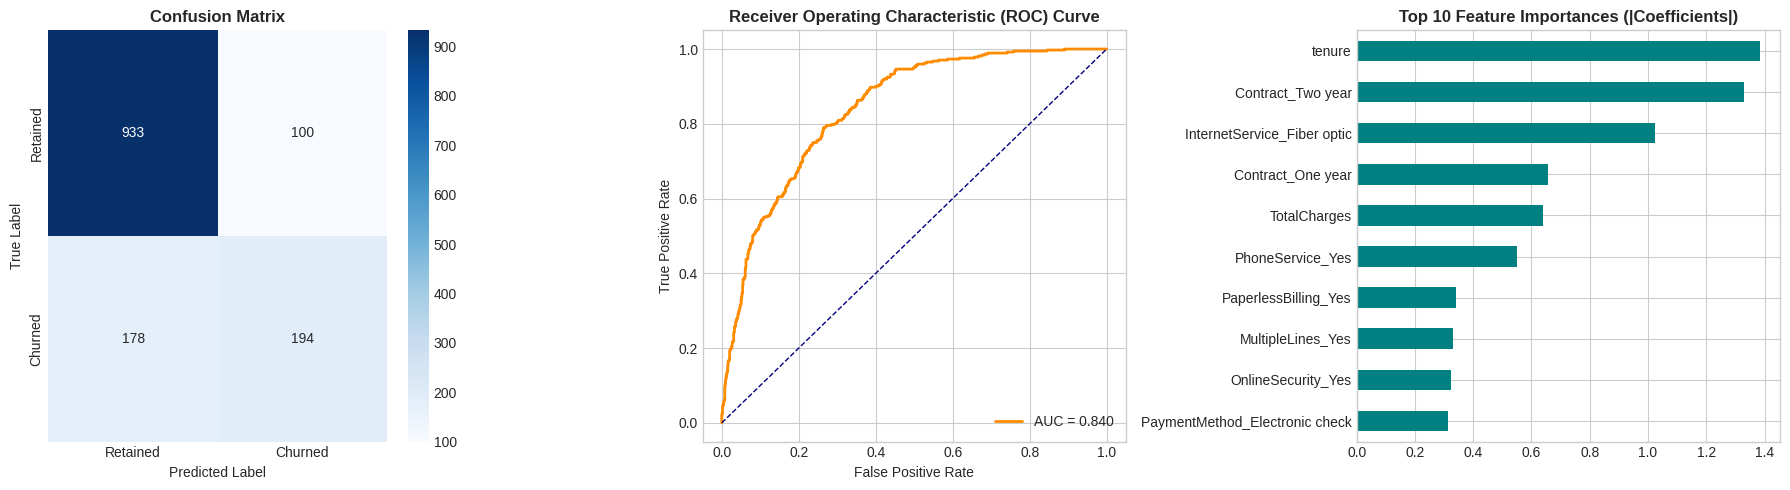


--- Classification Report ---
              precision    recall  f1-score   support

Retained (0)       0.84      0.90      0.87      1033
 Churned (1)       0.66      0.52      0.58       372

    accuracy                           0.80      1405
   macro avg       0.75      0.71      0.73      1405
weighted avg       0.79      0.80      0.79      1405



In [6]:
# Detailed Diagnostics for Best Model

best_model = LogisticRegression(max_iter=1000, random_state=42)
best_model.fit(X_train_scaled, y_train)

y_pred = best_model.predict(X_test_scaled)
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Retained', 'Churned'], yticklabels=['Retained', 'Churned'])
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc_score(y_test, y_proba):.3f}')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=12, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

# 3. Top 10 Feature Importance (Logistic Regression Coefficients)
coefs = pd.Series(abs(best_model.coef_[0]), index=X.columns).sort_values(ascending=False).head(10)
coefs.plot(kind='barh', ax=axes[2], color='teal')
axes[2].set_title('Top 10 Feature Importances (|Coefficients|)', fontsize=12, fontweight='bold')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Retained (0)', 'Churned (1)']))

## Key Business Insights

Based on descriptive analytics and model coefficient feature importance:

1. **Contract Structure is Paramount:**
   - Customers on **Month-to-month contracts** display the highest probability of churn (~42%). In contrast, 1-year and 2-year contract holders exhibit churn rates below 11% and 3% respectively.

2. **Early Tenure Vulnerability:**
   - The risk of churn is heavily concentrated in the **first 1–12 months** of customer lifespan. Once tenure passes 24 months, churn drops sharply.

3. **Fiber Optic & Monthly Cost Friction:**
   - Fiber Optic internet customers churn significantly higher than DSL or No-Internet users, driven by higher monthly charges ($70–$110 range) and potentially unmet service reliability expectations.

4. **Payment Channel Friction:**
   - Customers using **Electronic Check** churn at nearly twice the rate of those on automated payment channels (Bank Transfer, Credit Card). Automated billing creates lower decision friction.

5. **Lack of Value-Added Service Adoption:**
   - Absence of add-ons such as *Online Security*, *Tech Support*, and *Device Protection* correlates strongly with higher churn risk.

## Strategic Business Recommendations & Future Scope

### Business Action Plan

* **Long-Term Contract Incentives:**
  Implement targeted discount programs or fee waivers (e.g., $5 off monthly for 12 months) for customers transitioning from month-to-month to annual commitments.

* **Targeted Early Onboarding (0–90 Days):**
  Establish proactive onboarding touchpoints, dedicated customer support check-ins, and free trial access to value-added services (Online Security / Tech Support) during the critical early tenure phase.

* **Automated Payment Migration Campaign:**
  Offer a small one-time billing credit ($10–$15) for customers who switch from Electronic Check to recurring Auto-Pay options (Credit Card / Bank Transfer).

* **Fiber Optic Service Quality Audit:**
  Review price-to-performance perception and technical support SLA for Fiber Optic plans to minimize price sensitivity and reduce customer dissatisfaction.

---

### Future Scope & Roadmap

* **Hyperparameter Tuning:** Implement `GridSearchCV` or `Optuna` on XGBoost and Random Forest models to further improve recall on high-value customers.
* **Executive Dashboarding:** Export key metrics and predictions to **Power BI / Tableau** for executive tracking.
* **Interactive Web App:** Deploy an interactive churn risk predictor using **Streamlit**.
* **CRM Integration:** Embed model scoring into Salesforce/HubSpot to automatically flag high-risk customers for retention teams.
* **Real-time Scoring Pipeline:** Build an API-backed real-time prediction service for continuous churn probability updates.